In [2]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_4182528/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [3]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300

model_bgc_dia_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc_dia.202411????????.nc"
model_bgc_dia_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc_dia.202411????????.nc"
model_bgc_dia_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc_dia.202411????????.nc"

variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2','DIC','DIC_ALT_CO2']
variables_cstar=['hDIC_sum','hDIC_ALT_CO2_sum','FG_CO2','FG_ALT_CO2']

model_bgc_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc.202411????????.nc"
model_bgc_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc.202411????????.nc"
model_bgc_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc.202411????????.nc"

model_cstar_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_cstar.202411????????.nc"
model_cstar_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_cstar.202411????????.nc"
model_cstar_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_cstar.202411????????.nc"

target_depth_levels=[1,2,3,4,5,6,7,8,9,10,15] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [6]:
import xarray as xr
import numpy as np
import glob

# =========================
# Ensemble members
# =========================
ensembles = ["CDR4", "CDR5", "CDR6"]

N = vert_levels
theta_s = theta_s_model
theta_b = theta_b_model
hc = hc_model

# =========================
# Load grid (only once)
# =========================
grid = xr.open_dataset(model_grid_path)

h = grid["h"].values
mask_rho = grid["mask_rho"].values.astype(bool)

eta, xi = h.shape

# =========================
# Vertical coordinates
# =========================
k_w = np.linspace(0, N, N + 1)
sigma_w = (k_w - N) / N


def Cs(sigma, theta_s, theta_b):
    C = (1 - np.cosh(theta_s * sigma)) / (np.cosh(theta_s) - 1)
    C = (np.exp(theta_b * C) - 1) / (1 - np.exp(-theta_b))
    return C


Cs_w = Cs(sigma_w, theta_s, theta_b)

sigma_w_3d = sigma_w[:, None, None]
Cs_w_3d = Cs_w[:, None, None]
h_3d = h[None, :, :]

S_w = (hc * sigma_w_3d + h_3d * Cs_w_3d) / (hc + h_3d)

# =========================
# Loop over ensembles
# =========================
for ens in ensembles:

    #print(f"\nProcessing ensemble {ens}")

    his_path = f"/home/x-uheede/S/Iceland3_MARBL_2024_{ens}/Iceland3_MARBL_2024_his.202411*.nc"

    ds = xr.open_mfdataset(
        his_path,
        combine='nested',
        concat_dim=["time"]
    )

    zeta = ds["zeta"]

    thickness_list = []

    for t in range(len(zeta.time)):

        #print(f"{ens} time {t+1}/{len(zeta.time)}")

        zeta_t = zeta.isel(time=t).values

        zeta_3d = zeta_t[None, :, :]

        z_w = zeta_3d + (zeta_3d + h_3d) * S_w

        thickness = np.diff(z_w, axis=0)

        thickness[:, ~mask_rho] = np.nan

        thickness_list.append(thickness)

    thickness_all = np.stack(thickness_list, axis=0)

    # =========================
    # Save as xarray
    # =========================
    thickness_da = xr.DataArray(
        thickness_all,
        dims=["time", "s_rho", "eta_rho", "xi_rho"],
        coords={
            "time": ds.time,
            "s_rho": np.arange(N),
            "eta_rho": ds.eta_rho,
            "xi_rho": ds.xi_rho,
        },
        name="cell_thickness"
    )

    out_file = f"Iceland3_cell_thickness_July2024_{ens}.nc"

    thickness_da.to_netcdf(out_file)

    print(f"Saved {out_file}")

print("\nAll ensembles processed")

Saved Iceland3_cell_thickness_July2024_CDR4.nc
Saved Iceland3_cell_thickness_July2024_CDR5.nc
Saved Iceland3_cell_thickness_July2024_CDR6.nc

All ensembles processed


In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
bgc_paths = {
    "CDR4": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc.202411????????.nc",
    "CDR5": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc.202411????????.nc",
    "CDR6": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc.202411????????.nc",
}

thickness_files = {
    "CDR4": "Iceland3_cell_thickness_July2024_CDR4.nc",
    "CDR5": "Iceland3_cell_thickness_July2024_CDR5.nc",
    "CDR6": "Iceland3_cell_thickness_July2024_CDR6.nc",
}

# =========================
# Grid
# =========================
grid = xr.open_dataset(model_grid_path)

pm = grid["pm"]
pn = grid["pn"]

area = 1 / (pm * pn)  # m2

# =========================
# Storage
# =========================
total_alk_timeseries = {}
surface_alk_fraction = {}

# =========================
# Loop over ensembles
# =========================
for ens in ["CDR4", "CDR5", "CDR6"]:

    print(f"\nProcessing {ens}")

    # ---------------------
    # Load ALK
    # ---------------------
    ds_bgc = xr.open_mfdataset(
        bgc_paths[ens],
        combine="nested",
        concat_dim="time"
    )

    ALK = ds_bgc["ALK"] - ds_bgc["ALK_ALT_CO2"]

    # ---------------------
    # Load thickness
    # ---------------------
    thickness = xr.open_dataset(
        thickness_files[ens]
    )["cell_thickness"]

    # ---------------------
    # Volume
    # ---------------------
    volume = thickness * area

    # =====================
    # Total ALK inventory
    # =====================
    total_alk = (ALK * volume).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )

    total_alk_timeseries[ens] = total_alk

    # =====================
    # Surface (upper two layers)
    # =====================
    ALK_surface = ALK.isel(s_rho=slice(58, 60))
    volume_surface = volume.isel(s_rho=slice(58, 60))

    surface_alk = (ALK_surface * volume_surface).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )

    # =====================
    # Fraction of total ALK in surface
    # =====================
    surface_fraction = surface_alk / total_alk

    surface_alk_fraction[ens] = surface_fraction

    print("done")


Processing CDR4
done

Processing CDR5
done

Processing CDR6
done


In [8]:
# =========================
# Convert dictionaries to Dataset
# =========================
ds_out = xr.Dataset()

for ens in ["CDR4", "CDR5", "CDR6"]:

    total_ts = total_alk_timeseries[ens]
    surface_ts = surface_alk_fraction[ens]

    # Apply same time shift used in plotting
    if ens == "CDR1":
        total_ts = total_ts.copy()
        surface_ts = surface_ts.copy()

        #total_ts["time"] = total_ts["time"] + 34
        surface_ts["time"] = surface_ts["time"] + 34

    ds_out[f"total_alk_{ens}"] = total_ts
    ds_out[f"surface_fraction_{ens}"] = surface_ts


# =========================
# Add metadata
# =========================
ds_out["total_alk_CDR4"].attrs["units"] = "mol"
ds_out["total_alk_CDR5"].attrs["units"] = "mol"
ds_out["total_alk_CDR6"].attrs["units"] = "mol"

ds_out["surface_fraction_CDR4"].attrs["units"] = "fraction"
ds_out["surface_fraction_CDR5"].attrs["units"] = "fraction"
ds_out["surface_fraction_CDR6"].attrs["units"] = "fraction"

ds_out.attrs["description"] = "Total alkalinity inventory and surface fraction (s_rho 58-59)"
ds_out.attrs["model"] = "Iceland3 MARBL July 2024"
ds_out.attrs["created_by"] = "ALK inventory calculation script"


# =========================
# Save NetCDF
# =========================
ds_out.to_netcdf(
    "Iceland3_total_alk_and_surface_fraction_2.nc"
)

print("NetCDF saved: Iceland3_total_alk_and_surface_fraction_2.nc")

/home/x-uheede/.conda/envs/2024.02-py311/roms-tools/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


NetCDF saved: Iceland3_total_alk_and_surface_fraction_2.nc


In [4]:
from roms_tools import Grid, ROMSOutput

grid = Grid.from_file(
    model_grid_path
)

#Only run this cell if grid is made in MATLABØ
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)


In [5]:
import xarray as xr
import numpy as np

# -----------------------------------
# Group paths (no cstar)
# -----------------------------------
path_dict = {
    "bgc_dia": [
        model_bgc_dia_path4,
        model_bgc_dia_path5,
        model_bgc_dia_path6,
    ],
    "bgc": [
        model_bgc_path4,
        model_bgc_path5,
        model_bgc_path6,
    ],
}

# -----------------------------------
# Variable lists
# -----------------------------------
var_dict = {
    "bgc_dia": variables_bgc_dia,
    "bgc": variables_bgc,
}

# -----------------------------------
# Loop and create roms_* and ds_* variables
# -----------------------------------
for key, paths in path_dict.items():

    for i, path in enumerate(paths, start=4):

        roms_obj = ROMSOutput(
            grid=grid,
            path=[path],
            use_dask=True,
        )

        globals()[f"roms_{key}{i}"] = roms_obj

        if var_dict[key] is not None:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
                var_names=var_dict[key],
            )
        else:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
            )

        globals()[f"ds_{key}{i}"] = ds

In [5]:
import xarray as xr
import numpy as np

# -----------------------------------
# CSTAR paths
# -----------------------------------
cstar_paths = [
    model_cstar_path4,
    model_cstar_path5,
    model_cstar_path6,
]

# -----------------------------------
# Loop: create ROMSOutput and ds objects
# -----------------------------------
for i, path in enumerate(cstar_paths, start=4):

    roms_obj = ROMSOutput(
        grid=grid,
        path=[path],
        use_dask=True,
    )

    # store ROMSOutput
    globals()[f"roms_cstar{i}"] = roms_obj

    # store raw dataset (no regridding)
    ds = roms_obj.ds

    globals()[f"ds_cstar{i}"] = ds

In [6]:
# -----------------------------------
# Sum CSTAR variables over s_rho
# -----------------------------------
cstar_roms_objects = [roms_cstar4, roms_cstar5, roms_cstar6]

for i, roms_obj in enumerate(cstar_roms_objects, start=1):

    ds = roms_obj.ds

    # vertical sum
    ds["hDIC_sum"] = ds["hDIC"].sum(dim="s_rho", skipna=True)
    ds["hDIC_ALT_CO2_sum"] = ds["hDIC_ALT_CO2"].sum(dim="s_rho", skipna=True)

    # store updated dataset
    globals()[f"ds_cstar{i}"] = ds

In [9]:
import logging
def remove_duplicate_times(ds):
    _, index = np.unique(ds.time.values, return_index=True)
    return ds.isel(time=index)
# -----------------------------------
# Logging setup
# -----------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logging.info("Starting CSTAR regridding workflow")

variables_cstar = [
    "hDIC_sum",
    "hDIC_ALT_CO2_sum",
    "FG_CO2",
    "FG_ALT_CO2",
]

# ===============================
# CSTAR 4
# ===============================
logging.info("Processing CSTAR 4")

ds4 = roms_cstar4.ds
ds4 = remove_duplicate_times(ds4)
logging.info("Loaded dataset for CSTAR 4")

ds4["hDIC_sum"] = ds4["hDIC"].sum("s_rho", skipna=True)
ds4["hDIC_ALT_CO2_sum"] = ds4["hDIC_ALT_CO2"].sum("s_rho", skipna=True)
logging.info("Computed hDIC sums for CSTAR 4")

roms_cstar4.ds = ds4

logging.info("Regridding CSTAR 4")
ds_cstar4_rg = roms_cstar4.regrid(
    depth_levels=target_depth_levels,
    var_names=variables_cstar,
)

logging.info("Saving CSTAR 5 to NetCDF")
ds_cstar4_rg.to_netcdf("ds_cstar4_regridded.nc")

logging.info("Finished CSTAR 4")


# ===============================
# CSTAR 5
# ===============================
logging.info("Processing CSTAR 5")

ds5 = roms_cstar5.ds
ds5 = remove_duplicate_times(ds5)
logging.info("Loaded dataset for CSTAR 5")

ds5["hDIC_sum"] = ds5["hDIC"].sum("s_rho", skipna=True)
ds5["hDIC_ALT_CO2_sum"] = ds5["hDIC_ALT_CO2"].sum("s_rho", skipna=True)
logging.info("Computed hDIC sums for CSTAR 5")

roms_cstar5.ds = ds5

logging.info("Regridding CSTAR 2")
ds_cstar5_rg = roms_cstar5.regrid(
    depth_levels=target_depth_levels,
    var_names=variables_cstar,
)

logging.info("Saving CSTAR 5 to NetCDF")
ds_cstar5_rg.to_netcdf("ds_cstar5_regridded.nc")

logging.info("Finished CSTAR 5")


# ===============================
# CSTAR 6
# ===============================
logging.info("Processing CSTAR 6")

ds6 = roms_cstar6.ds
ds6 = remove_duplicate_times(ds6)
logging.info("Loaded dataset for CSTAR 6")

ds6["hDIC_sum"] = ds6["hDIC"].sum("s_rho", skipna=True)
ds6["hDIC_ALT_CO2_sum"] = ds6["hDIC_ALT_CO2"].sum("s_rho", skipna=True)
logging.info("Computed hDIC sums for CSTAR 6")

roms_cstar6.ds = ds6

logging.info("Regridding CSTAR 3")
ds_cstar6_rg = roms_cstar6.regrid(
    depth_levels=target_depth_levels,
    var_names=variables_cstar,
)

logging.info("Saving CSTAR 6 to NetCDF")
ds_cstar6_rg.to_netcdf("ds_cstar6_regridded.nc")

logging.info("Finished CSTAR 6")

logging.info("All CSTAR regridding completed successfully")

2026-04-20 12:54:13,856 | INFO | Starting CSTAR regridding workflow
2026-04-20 12:54:13,857 | INFO | Processing CSTAR 4
2026-04-20 12:54:13,875 | INFO | Loaded dataset for CSTAR 4
2026-04-20 12:54:13,886 | INFO | Computed hDIC sums for CSTAR 4
2026-04-20 12:54:13,887 | INFO | Regridding CSTAR 4
2026-04-20 12:54:24,085 | INFO | Saving CSTAR 5 to NetCDF
2026-04-20 12:57:17,202 | INFO | Finished CSTAR 4
2026-04-20 12:57:17,203 | INFO | Processing CSTAR 5
2026-04-20 12:57:17,594 | INFO | Loaded dataset for CSTAR 5
2026-04-20 12:57:17,608 | INFO | Computed hDIC sums for CSTAR 5
2026-04-20 12:57:17,608 | INFO | Regridding CSTAR 2
2026-04-20 12:57:27,777 | INFO | Saving CSTAR 5 to NetCDF
2026-04-20 13:00:49,485 | INFO | Finished CSTAR 5
2026-04-20 13:00:49,487 | INFO | Processing CSTAR 6
2026-04-20 13:00:49,884 | INFO | Loaded dataset for CSTAR 6
2026-04-20 13:00:49,905 | INFO | Computed hDIC sums for CSTAR 6
2026-04-20 13:00:49,906 | INFO | Regridding CSTAR 3
2026-04-20 13:01:00,822 | INFO |

In [7]:
def remove_duplicate_time(ds):
    _, index = np.unique(ds["time"], return_index=True)
    return ds.isel(time=index)

ds_bgc_dia4 = remove_duplicate_time(ds_bgc_dia4)
ds_bgc_dia5 = remove_duplicate_time(ds_bgc_dia5)
ds_bgc_dia6 = remove_duplicate_time(ds_bgc_dia6)

ds_bgc4 = remove_duplicate_time(ds_bgc4)
ds_bgc5 = remove_duplicate_time(ds_bgc5)
ds_bgc6 = remove_duplicate_time(ds_bgc6)

ds_cstar4 = remove_duplicate_time(ds_cstar4)
ds_cstar5 = remove_duplicate_time(ds_cstar5)
ds_cstar6 = remove_duplicate_time(ds_cstar6)




[2026-04-20 11:59:03] --- STARTING CDR METRICS ONLY FOR CDR6 ---
[2026-04-20 11:59:03] Initializing CSTAR ROMSOutput object...
[2026-04-20 11:59:04] Removing duplicate time steps...
[2026-04-20 11:59:04] Computing CDR metrics (this triggers Dask computations)...


2026-04-20 12:04:31 - INFO - Max absolute difference between flux-based and DIC-based uptake efficiency: 8.942e-06


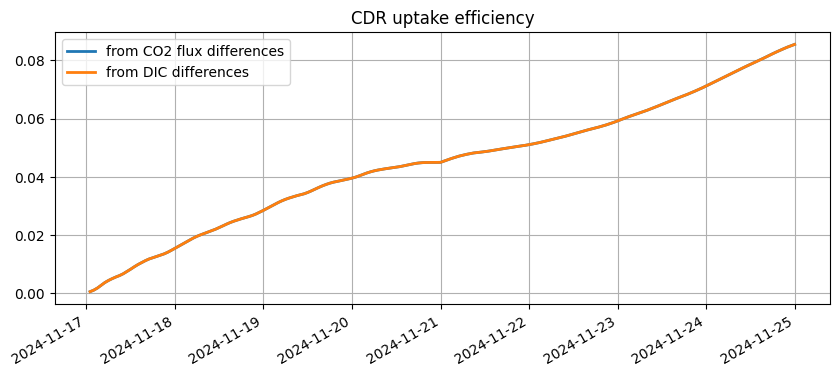

KeyboardInterrupt: 

In [20]:
import datetime

def log(message):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{timestamp}] {message}")

# --- Configuration for this specific cell ---
i = 6  # Change this to 4, 5, or 6
cstar_path = model_cstar_path6 # Ensure path matches 'i'
label = f"CDR{i}"

log(f"--- STARTING CDR METRICS ONLY FOR {label} ---")

# 1. Initialize ONLY the CSTAR object (contains the DIC/ALT_CO2 data)
log("Initializing CSTAR ROMSOutput object...")
roms_cstar = ROMSOutput(grid=grid, path=[cstar_path], use_dask=True)

# 3. Clean duplicates immediately
# This is the "fix" for the plotting error within cdr_metrics()
log("Removing duplicate time steps...")
roms_cstar.ds = remove_duplicate_time(roms_cstar.ds)

# 4. Compute CDR Metrics
# This calculates uptake efficiency, air-sea flux, and total inventory
log("Computing CDR metrics (this triggers Dask computations)...")
ds_cdr = roms_cstar.cdr_metrics() 

# 5. Save output
output_filename = f"Iceland3_{label}_cdr_metrics.nc"
roms_cstar.ds_cdr.to_netcdf(output_filename)
log(f"SUCCESS: Saved {output_filename}")

log(f"--- COMPLETED {label} ---")

In [23]:
def get_start_time(ds, threshold=1e-6):
    diff = (ds["ALK"].isel(depth=0).load() - ds["ALK_ALT_CO2"].isel(depth=0).load())

    # domain max to detect any signal
    signal = diff.max(dim=("lat", "lon"))

    # first time where signal exceeds threshold
    t0 = signal.where(signal > threshold, drop=True).time.min()

    return t0

def add_relative_time(ds, t0):
    time_rel = (ds.time - t0) / np.timedelta64(1, "h")
    return ds.assign_coords(time_rel=("time", time_rel.data))



In [ ]:
# Compute start times
t0_4 = get_start_time(ds_bgc4)
t0_5 = get_start_time(ds_bgc5)
t0_6 = get_start_time(ds_bgc6)

# Add relative time

ds_bgc4 = add_relative_time(ds_bgc4, t0_4)
ds_bgc5 = add_relative_time(ds_bgc5, t0_5)
ds_bgc6 = add_relative_time(ds_bgc6, t0_6)

ds_bgc4 = ds_bgc4.swap_dims({"time": "time_rel"})
ds_bgc5 = ds_bgc5.swap_dims({"time": "time_rel"})
ds_bgc6 = ds_bgc6.swap_dims({"time": "time_rel"})

time_rel_common = np.arange(-48, 240, 1)  # hours

ds_bgc4 = ds_bgc4.interp(time_rel=time_rel_common)
ds_bgc5 = ds_bgc5.interp(time_rel=time_rel_common)
ds_bgc6 = ds_bgc6.interp(time_rel=time_rel_common)

In [ ]:
ds_bgc_dia4 = add_relative_time(ds_bgc_dia4, t0_4)
ds_bgc_dia5 = add_relative_time(ds_bgc_dia5, t0_5)
ds_bgc_dia6 = add_relative_time(ds_bgc_dia6, t0_6)

ds_bgc_dia4 = ds_bgc_dia4.swap_dims({"time": "time_rel"})
ds_bgc_dia5 = ds_bgc_dia5.swap_dims({"time": "time_rel"})
ds_bgc_dia6 = ds_bgc_dia6.swap_dims({"time": "time_rel"})

time_rel_common = np.arange(-48, 240, 1)  # hours

ds_bgc_dia4 = ds_bgc_dia4.interp(time_rel=time_rel_common)
ds_bgc_dia5 = ds_bgc_dia5.interp(time_rel=time_rel_common)
ds_bgc_dia6 = ds_bgc_dia6.interp(time_rel=time_rel_common)

In [ ]:
ds_cstar4 = add_relative_time(ds_cstar4, t0_4)
ds_cstar5 = add_relative_time(ds_cstar5, t0_5)
ds_cstar6 = add_relative_time(ds_cstar6, t0_6)

ds_cstar4 = ds_cstar4.swap_dims({"time": "time_rel"})
ds_cstar5 = ds_cstar5.swap_dims({"time": "time_rel"})
ds_cstar6 = ds_cstar6.swap_dims({"time": "time_rel"})

time_rel_common = np.arange(-48, 240, 1)  # hours

ds_cstar4 = ds_cstar4.interp(time_rel=time_rel_common)
ds_cstar5 = ds_cstar5.interp(time_rel=time_rel_common)
ds_cstar6 = ds_cstar6.interp(time_rel=time_rel_common)

In [ ]:
ds_bgc_dia_ens = xr.concat(
    [ds_bgc_dia4, ds_bgc_dia5, ds_bgc_dia6],
    dim="ens"
)

ds_bgc_ens = xr.concat(
    [ds_bgc4, ds_bgc5, ds_bgc6],
    dim="ens"
)

ds_cstar_ens = xr.concat(
    [ds_cstar4, ds_cstar5, ds_cstar6],
    dim="ens"
)

# label ensembles
ens_labels = ["CDR4", "CDR5", "CDR6"]

ds_bgc_dia_ens["ens"] = ens_labels
ds_bgc_ens["ens"] = ens_labels
ds_cstar_ens["ens"] = ens_labels

In [ ]:
pCO2SURF_anom = ds_bgc_dia_ens["pCO2SURF"] - ds_bgc_dia_ens["pCO2SURF_ALT_CO2"]
PH_anom = ds_bgc_dia_ens["pH_3D"]

min_pCO2SURF = pCO2SURF_anom.min(
    dim=["lat", "lon"],
    skipna=True
)

max_PH = PH_anom.max(
    dim=["depth", "lat", "lon"],
    skipna=True
)

ALK_anom = ds_bgc_ens["ALK"] - ds_bgc_ens["ALK_ALT_CO2"]
DIC_anom = ds_bgc_ens["DIC"] - ds_bgc_ens["DIC_ALT_CO2"]

# --------------------------------
# Max alkalinity (all depths)
# --------------------------------
max_ALK = ALK_anom.max(
    dim=["depth", "lat", "lon"],
    skipna=True
)

# --------------------------------
# Max surface alkalinity
# --------------------------------
ALK_surface = ALK_anom.isel(depth=0)

max_ALK_surface = ALK_surface.max(
    dim=["lat", "lon"],
    skipna=True
)

# --------------------------------
# Max DIC
# --------------------------------
max_DIC = DIC_anom.max(
    dim=["depth", "lat", "lon"],
    skipna=True
)

# --------------------------------
# Save dataset
# --------------------------------
ds_metrics = xr.Dataset(
    {
        "min_pCO2SURF_anom": min_pCO2SURF.load(),
        "max_PH_anom": max_PH.load(),
        "max_ALK_anom": max_ALK.load(),
        "max_ALK_surface_anom": max_ALK_surface.load(),
        "max_DIC_anom": max_DIC.load(),
    }
)

ds_metrics.attrs["description"] = "CDR ensemble extrema diagnostics"
ds_metrics.attrs["model"] = "Iceland3 MARBL July 2024"

ds_metrics.to_netcdf("Iceland3_CDR_extrema_metrics_pt2.nc")

print("Saved Iceland3_CDR_extrema_metrics_pt2.nc")

In [12]:
import xarray as xr

# =========================
# Select time window (0–96 hours)
# =========================
time_sel_dia = ds_bgc_dia_ens.sel(time_rel=slice(0, 96))
time_sel_bgc = ds_bgc_ens.sel(time_rel=slice(0, 96))

# =========================
# Compute anomalies
# =========================
pCO2SURF_anom = (
    time_sel_dia["pCO2SURF"]
    - time_sel_dia["pCO2SURF_ALT_CO2"]
)

PH_anom = (
    time_sel_dia["pH_3D"])

ALK_anom = (
    time_sel_bgc["ALK"]
    - time_sel_bgc["ALK_ALT_CO2"]
)

DIC_anom = (
    time_sel_bgc["DIC"]
    - time_sel_bgc["DIC_ALT_CO2"]
)

# =========================
# Select 1 m depth
# =========================
pCO2SURF_1m = pCO2SURF_anom
PH_1m = PH_anom.sel(depth=1, method="nearest")
ALK_1m = ALK_anom.sel(depth=1, method="nearest")
DIC_1m = DIC_anom.sel(depth=1, method="nearest")

# =========================
# Time mean (0–96 hours)
# =========================
pCO2SURF_mean = pCO2SURF_1m.mean(dim="time_rel", skipna=True).load()
PH_mean = PH_1m.mean(dim="time_rel", skipna=True).load()
ALK_mean = ALK_1m.mean(dim="time_rel", skipna=True).load()
DIC_mean = DIC_1m.mean(dim="time_rel", skipna=True).load()

# =========================
# Save each as NetCDF
# =========================
encoding = {"zlib": True, "complevel": 4}

#pCO2SURF_mean.to_netcdf(
#    "Iceland3_pCO2SURF_1m_time0_96_mean_pt2.nc")

#PH_mean.to_netcdf(
#    "Iceland3_PH_1m_time0_96_mean_pt2.nc",
#    encoding={"pH_3D": encoding}
#)

ALK_mean.to_netcdf(
    "Iceland3_ALK_1m_time0_96_mean_pt2.nc"
)

#DIC_mean.to_netcdf(
#    "Iceland3_DIC_1m_time0_96_mean_pt2.nc",
#    encoding={"DIC": encoding}
#)

print("Saved 1m time-mean anomaly fields pt2")

KeyError: 'ALK'

In [14]:
DIC_mean.to_netcdf(
    "Iceland3_DIC_1m_time0_96_mean_pt2.nc"
)

In [9]:
import numpy as np
import xarray as xr

def remove_duplicate_time(ds):
    """
    Ensures the time index is strictly monotonic by keeping only 
    the first instance of any duplicate timestamp.
    """
    _, index = np.unique(ds["time"], return_index=True)
    return ds.isel(time=index)

def get_cstar_start_time(ds, threshold=1e-9):
    """
    Detects injection start time based on the air-sea CO2 flux anomaly.
    """
    # Calculate flux anomaly (absolute difference)
    flux_anom = np.abs(ds["FG_CO2"] - ds["FG_ALT_CO2"])
    
    # Take the spatial maximum to detect the very first signal
    signal = flux_anom.max(dim=("lat", "lon")).load()
    
    # Find the first time where the signal exceeds our threshold
    t0 = signal.where(signal > threshold, drop=True).time.min()
    
    return t0

def add_relative_time(ds, t0):
    """
    Adds a 'time_rel' coordinate (hours) relative to t0.
    """
    time_rel = (ds.time - t0) / np.timedelta64(1, "h")
    return ds.assign_coords(time_rel=("time", time_rel.data))

In [13]:
import xarray as xr
import numpy as np

# --- Helper Functions ---
def remove_duplicate_time(ds):
    _, index = np.unique(ds["time"], return_index=True)
    return ds.isel(time=index)

def get_cstar_start_time(ds, threshold=1e-9):
    # Detect injection start time based on the air-sea CO2 flux anomaly
    flux_anom = np.abs(ds["FG_CO2"] - ds["FG_ALT_CO2"])
    signal = flux_anom.max(dim=("lat", "lon")).load()
    return signal.where(signal > threshold, drop=True).time.min()

# --- Setup ---
files = {
    "CDR4": "ds_cstar4_regridded.nc",
    "CDR5": "ds_cstar5_regridded.nc",
    "CDR6": "ds_cstar6_regridded.nc"
}
ens_labels = list(files.keys())
ds_list = []

print("Processing members for Cumulative Fields (Cleaned Workflow)...")

for label, path in files.items():
    # 1. Load and Clean
    ds_member = xr.open_dataset(path)
    ds_member = remove_duplicate_time(ds_member)
    
    # 2. Alignment Logic using Flux Anomaly
    t0 = get_cstar_start_time(ds_member)
    
    # Calculate relative time (hours)
    time_rel_hours = (ds_member.time - t0) / np.timedelta64(1, "h")
    ds_member = ds_member.assign_coords(time_rel=("time", time_rel_hours.data))
    
    # Swap to relative time and slice to start at 0
    ds_member = ds_member.swap_dims({"time": "time_rel"})
    ds_member = ds_member.sel(time_rel=slice(0, None))
    
    # 3. Interpolate to a common hourly grid (Fixes length mismatches)
    # This ensures CDR4, 5, and 6 all have the same coordinates for concat
    common_hours = np.arange(0, 241, 1) # Adjust 241 based on your run length
    ds_member = ds_member.interp(time_rel=common_hours)
    
    # 4. Compute Anomalies and Cumulative Sums
    # FG_anom in mmol/m2/s
    ds_member["FG_anom"] = ds_member["FG_CO2"] - ds_member["FG_ALT_CO2"]
    
    # Cumulative sum (assuming hourly steps, multiply by 3600 for total mmol/m2)
    ds_member["FG_CO2_cumsum_anom"] = ds_member["FG_anom"].cumsum(dim="time_rel") * 3600.0
    
    # Inventory (hDIC) anomaly
    ds_member["hDIC_anom"] = ds_member["hDIC_sum"] - ds_member["hDIC_ALT_CO2_sum"]
    
    # 5. Cleanup for Ensemble
    ds_to_append = ds_member[["FG_CO2_cumsum_anom", "hDIC_anom"]]
    ds_list.append(ds_to_append.load()) # Load here to speed up concat
    
    print(f" - {label}: Processed and aligned at t_rel=0")

# 6. Concatenate into Ensemble
print("Concatenating ensemble...")
ds_ens = xr.concat(ds_list, dim="ens").assign_coords(ens=ens_labels)

# 7. Add Metadata
ds_ens.attrs["description"] = "Cumulative FG_CO2 and hDIC anomalies per grid cell (Cleaned & Aligned)"
ds_ens.attrs["model"] = "Iceland3 MARBL July 2024"

ds_ens["FG_CO2_cumsum_anom"].attrs["units"] = "mmol/m^2"
ds_ens["FG_CO2_cumsum_anom"].attrs["long_name"] = "Cumulative air-sea CO2 flux anomaly (time integrated)"

ds_ens["hDIC_anom"].attrs["units"] = "mmol/m^2"
ds_ens["hDIC_anom"].attrs["long_name"] = "hDIC inventory anomaly (vertically integrated)"

# 8. Save
output_path = "Iceland3_CDR_cstar_cumsum_fields_pt2.nc"
ds_ens.to_netcdf(output_path)

print(f"Successfully saved: {output_path}")

Processing members for Cumulative Fields (Cleaned Workflow)...
 - CDR4: Processed and aligned at t_rel=0
 - CDR5: Processed and aligned at t_rel=0
 - CDR6: Processed and aligned at t_rel=0
Concatenating ensemble...
Successfully saved: Iceland3_CDR_cstar_cumsum_fields_pt2.nc
